# Fine-tuned Model + CNN Microphone Recording Demo
### Install and Import Libraries

In [37]:
!pip install librosa matplotlib numpy pandas pydub pretty_midi

In [38]:
# ========================
# System / File Handling
# ========================
import os
import pickle
from io import BytesIO
from base64 import b64decode

# ========================
# Data Handling
# ========================
import numpy as np
import pandas as pd

# ========================
# Audio Processing
# ========================
import librosa
import librosa.display
import pretty_midi
import pydub

# ========================
# Machine Learning / Deep Learning
# ========================
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoProcessor
from peft import PeftModel

# ========================
# Visualization
# ========================
import matplotlib.pyplot as plt

# ========================
# Google Colab Utilities
# ========================
from google.colab import drive, output

# ========================
# Interactive / Display
# ========================
import IPython

In [23]:
# Clone the repository to access the reference MIDI files
!git clone https://github.com/mperumal-usd/capstone_team_3.git
MIDI_ROOT = "/content/capstone_team_3/MidiDatasets/590-Classical-music-midi"

fatal: destination path 'capstone_team_3' already exists and is not an empty directory.


# MyDrive Shortcut Setup
Open the Shared Drive or the Shared with me section in your Google Drive.

Download the following files:
1) adapter_model.safetensors - https://drive.google.com/drive/u/1/folders/1ACWI_rjz5uXnk8UZmXCjzWOCsf7AJ2g2
2) adapter_config.json
3) all_embeddings.pkl - https://drive.google.com/file/d/1CPxkjS4eegrNHGfEyqpRGNuBBdCB_H-L/view?usp=sharing

Download to "My Drive/AAI-590 Capstone/model_embed"

In [4]:
# 0. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
!ls "/content/drive/MyDrive/AAI-590 Capstone/"

ChunkSamples  model_embed


# Load base MERT model

In [6]:
# Section 1 - load base model

# Model Configuration
MODEL_NAME = "m-a-p/MERT-v1-95M"
SR = 24000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load the Base MERT Model & Processor
processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
base_model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True).to(DEVICE)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- configuration_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
The image processor of type `Wav2Vec2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


modeling_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- modeling_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [7]:
# Loading embeddings and ft model
# 2. Load fine-tuned LoRA weights
# Point to the FOLDER, not the .safetensors file
# Define your project directory
DRIVE_PATH = "/content/drive/MyDrive/AAI-590 Capstone/model_embed"
LORA_FOLDER_PATH = DRIVE_PATH

print(f"Loading LoRA weights from folder: {LORA_FOLDER_PATH}")

# PEFT looks for adapter_config.json and adapter_model.safetensors inside this folder
model = PeftModel.from_pretrained(base_model, LORA_FOLDER_PATH).to(DEVICE)
model.eval()



Loading LoRA weights from folder: /content/drive/MyDrive/AAI-590 Capstone/model_embed


PeftModel(
  (base_model): LoraModel(
    (model): MERTModel(
      (feature_extractor): HubertFeatureEncoder(
        (conv_layers): ModuleList(
          (0): HubertGroupNormConvLayer(
            (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
            (activation): GELUActivation()
            (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
          )
          (1-4): 4 x HubertNoLayerNormConvLayer(
            (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
            (activation): GELUActivation()
          )
          (5-6): 2 x HubertNoLayerNormConvLayer(
            (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
            (activation): GELUActivation()
          )
        )
      )
      (feature_projection): MERTFeatureProjection(
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (projection): Linear(in_features=512, out_features=768, bias=True)
        (dropout): Dr

In [8]:
# 3. Load the 128 dim reference Embeddings
REF_EMB_PATH = os.path.join(DRIVE_PATH, "all_embeddings.pkl")

with open(REF_EMB_PATH, 'rb') as f:
    ref_df = pickle.load(f)

# Extract embeddings and filenames from the DataFrame columns
# np.stack is used to convert the series of arrays into a single 2D matrix
ref_embeddings = torch.tensor(np.stack(ref_df['embeddings'].values)).to(DEVICE)

# Create the reference list (combining filename and chunk if you want unique IDs)
ref_names = ref_df['filename'].tolist()

print(f"Success: Loaded {len(ref_names)} reference embeddings.")
print(f"Embedding shape: {ref_embeddings.shape}") # Should be [Number of Chunks, 128]

Success: Loaded 43663 reference embeddings.
Embedding shape: torch.Size([43663, 128])


In [9]:
# Check type
print("Type:", type(ref_names))

# If list → inspect contents
if isinstance(ref_names, list):
    print("Length:", len(ref_names))
    print("First item:", ref_names[0])

# If dict → keys
elif isinstance(ref_names, dict):
    print("Keys:", ref_names.keys())

# If DataFrame → columns
elif isinstance(ref_names, pd.DataFrame):
    print("Columns:", ref_names.columns.tolist())

Type: <class 'list'>
Length: 43663
First item: bach_847_chunk_1.wav


# Capture microphone audio
setTimeout(r, 7000): The number 7000 is in milliseconds.

In [40]:


SAMPLING_RATE = 24000
SECONDS = 5
def record_7_seconds(sr=SAMPLING_RATE, seconds=SECONDS):
    JS_CODE = f"""
    async function recordAudio() {{
      const stream = await navigator.mediaDevices.getUserMedia({{ audio: true }});
      const mediaRecorder = new MediaRecorder(stream);
      let chunks = [];
      mediaRecorder.ondataavailable = (e) => chunks.push(e.data);
      mediaRecorder.start();
      await new Promise(r => setTimeout(r, {seconds * 1000}));
      mediaRecorder.stop();
      return new Promise(r => mediaRecorder.onstop = () => {{
        const blob = new Blob(chunks);
        const reader = new FileReader();
        reader.readAsDataURL(blob);
        reader.onloadend = () => r(reader.result);
      }});
    }}
    """
    print(f'Recording for {SECONDS} seconds...')
    display(IPython.display.Javascript(JS_CODE))
    audio_data = output.eval_js('recordAudio()')

    # Convert base64 to audio array
    binary = b64decode(audio_data.split(',')[1])
    audio = pydub.AudioSegment.from_file(BytesIO(binary))
    samples = np.array(audio.get_array_of_samples()).astype(np.float32)

    # Resample to match your MERT model requirements (24kHz)
    samples_resampled = librosa.resample(samples, orig_sr=audio.frame_rate, target_sr=sr)
    return samples_resampled

# Capture the audio
full_audio = record_7_seconds(sr=SAMPLING_RATE)

Recording for 5 seconds...


<IPython.core.display.Javascript object>

In [41]:
# Create MERT inputs from audio
inputs = processor(
    full_audio,
    sampling_rate=24000,
    return_tensors="pt",
    padding=True
).to(DEVICE)

In [42]:
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(f"Layer: {name} | In: {module.in_features} | Out: {module.out_features}")

Layer: base_model.model.feature_projection.projection | In: 512 | Out: 768
Layer: base_model.model.encoder.layers.0.attention.k_proj.base_layer | In: 768 | Out: 768
Layer: base_model.model.encoder.layers.0.attention.k_proj.lora_A.default | In: 768 | Out: 8
Layer: base_model.model.encoder.layers.0.attention.k_proj.lora_B.default | In: 8 | Out: 768
Layer: base_model.model.encoder.layers.0.attention.v_proj.base_layer | In: 768 | Out: 768
Layer: base_model.model.encoder.layers.0.attention.v_proj.lora_A.default | In: 768 | Out: 8
Layer: base_model.model.encoder.layers.0.attention.v_proj.lora_B.default | In: 8 | Out: 768
Layer: base_model.model.encoder.layers.0.attention.q_proj.base_layer | In: 768 | Out: 768
Layer: base_model.model.encoder.layers.0.attention.q_proj.lora_A.default | In: 768 | Out: 8
Layer: base_model.model.encoder.layers.0.attention.q_proj.lora_B.default | In: 8 | Out: 768
Layer: base_model.model.encoder.layers.0.attention.out_proj | In: 768 | Out: 768
Layer: base_model.mode

# Load CNN Head Checkpoint "cnn_head_best.pt"

In [ ]:
import os
import torch
import torch.nn as nn

# Define the exact architecture from your v5 training notebook
class CNNProjectionHead(nn.Module):
    def __init__(self, input_dim=768, output_dim=128):
        super().__init__()

        # Parallel conv branches
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(input_dim, 256, kernel_size=3, padding=1),
                nn.BatchNorm1d(256),
                nn.ReLU()
            ),
            nn.Sequential(
                nn.Conv1d(input_dim, 256, kernel_size=5, padding=2),
                nn.BatchNorm1d(256),
                nn.ReLU()
            ),
            nn.Sequential(
                nn.Conv1d(input_dim, 256, kernel_size=7, padding=3),
                nn.BatchNorm1d(256),
                nn.ReLU()
            )
        ])

        self.pool = nn.AdaptiveAvgPool1d(1)

        # 256 * 3 = 768
        self.proj = nn.Sequential(
            nn.Linear(768, 384),      # proj.0
            nn.BatchNorm1d(384, track_running_stats=False),
            nn.ReLU(),                # proj.2
            nn.Dropout(0.1),          # proj.3
            nn.Linear(384, output_dim) # proj.4
        )

    def forward(self, x):
        x = x.transpose(1, 2)  # [B, 768, T]

        conv_outputs = []
        for conv in self.convs:
            out = conv(x)
            out = self.pool(out).squeeze(-1)
            conv_outputs.append(out)

        x = torch.cat(conv_outputs, dim=1)  # [B, 768]
        return self.proj(x)

# Set your path and load the weights
DRIVE_PATH = "/content/drive/MyDrive/AAI-590 Capstone/model_embed"
checkpoint_file = os.path.join(DRIVE_PATH, "cnn_head_best.pt")

state_dict = torch.load(checkpoint_file, map_location=DEVICE)

trained_projector = CNNProjectionHead(input_dim=768, output_dim=128).to(DEVICE)

missing, unexpected = trained_projector.load_state_dict(state_dict, strict=False)

trained_projector.eval()

print("Missing:", missing)
print("Unexpected:", unexpected)
print(f"Successfully loaded trained weights from: {checkpoint_file}")

# Find best match with Fine-Tuned MERT with LoRA + CNN


In [43]:
# This will show 'Missing' for proj.1, but NO 'Unexpected' for convs.
# The 'Missing' keys for proj.1 are fine; they will use default values.
trained_projector.load_state_dict(state_dict, strict=False)
trained_projector.eval() # CRITICAL

# 1. RUN THE MATCHING (This time appending to chunks_results)
chunks_results = [] # Clear previous runs

try:
    with torch.no_grad():
        inputs = processor(input_audio, sampling_rate=SAMPLING_RATE, return_tensors="pt").to(DEVICE)
        outputs = model(**inputs, output_hidden_states=True)
        last_hidden = outputs.last_hidden_state

        # BatchNorm Safety Trick
        fake_batch = torch.cat([last_hidden, last_hidden], dim=0)
        chunk_emb = trained_projector(fake_batch)[0:1]

        # Similarity Search
        chunk_emb_norm = F.normalize(chunk_emb, p=2, dim=1)
        ref_norm = F.normalize(ref_embeddings, p=2, dim=1)
        similarities = torch.mm(chunk_emb_norm, ref_norm.T).squeeze(0)

        top_idx = torch.argmax(similarities).item()
        score = similarities[top_idx].item()
        song_name = ref_names[top_idx]

        # CRITICAL: Append to the list so the visualization block can see it
        chunks_results.append({
            "Matched_File": song_name,
            "Sim Score": score
        })

        print(f"Top Match: {song_name} | Score: {score:.4f}")

except Exception as e:
    print(f"Error during matching: {e}")


Top Match: waldstein_1_chunk_125.wav | Score: 0.8007


# Plot transcribed piano roll with reference piano roll

Match found! Processing transcription for: /content/capstone_team_3/MidiDatasets/590-Classical-music-midi/beeth/waldstein_1.mid


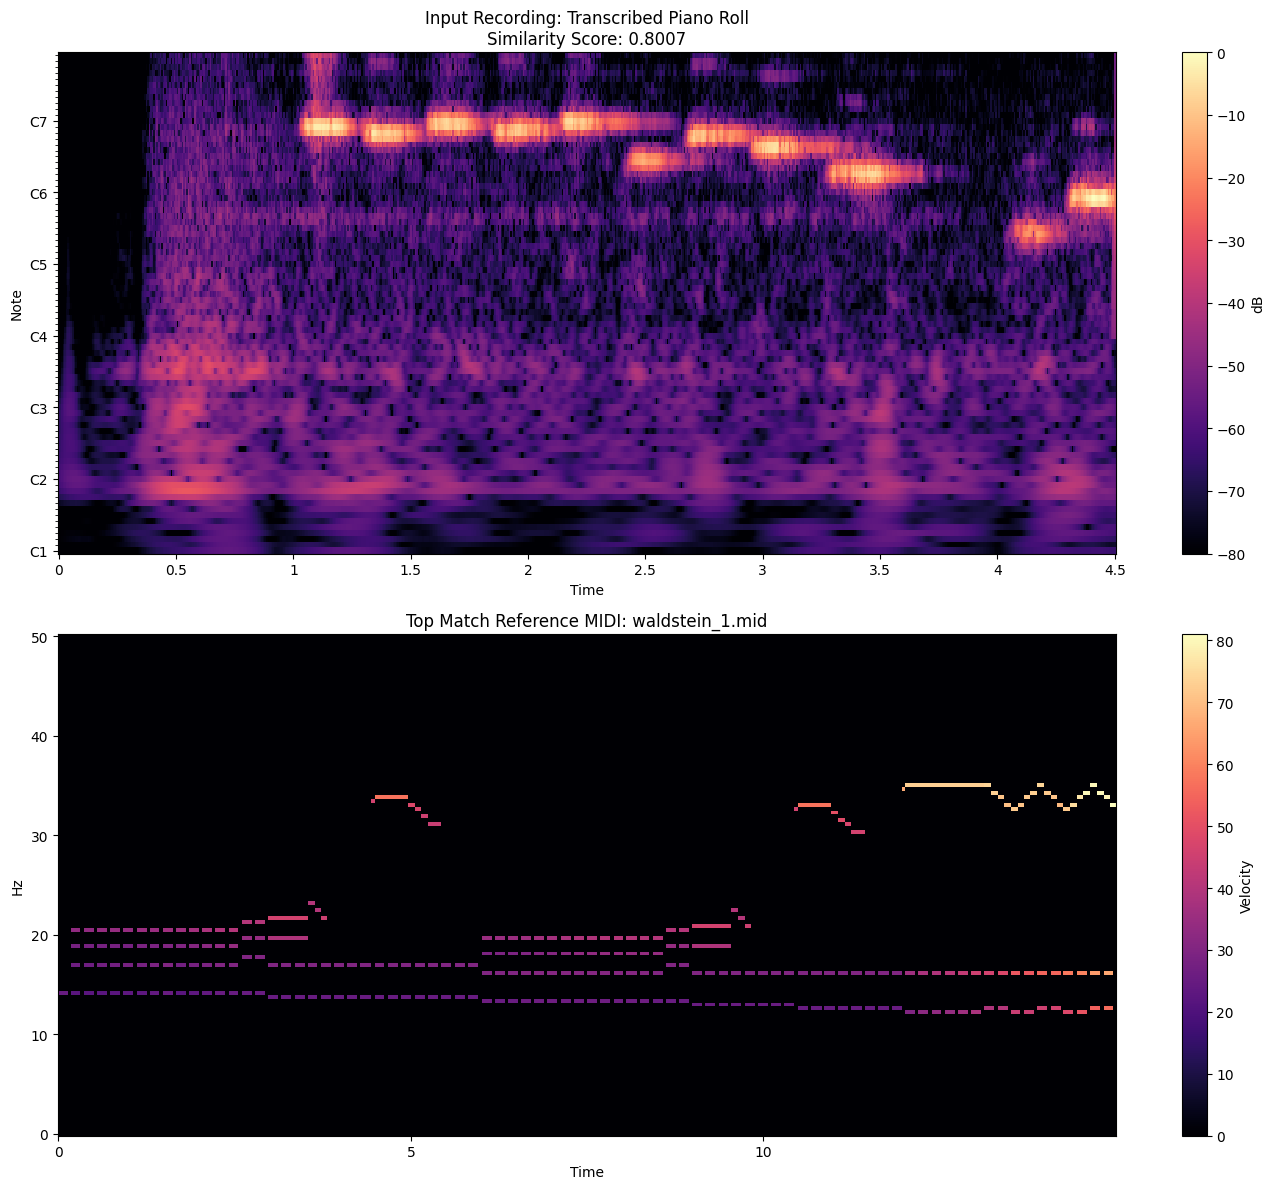

In [45]:
# 2. RUN THE ENHANCED VISUALIZATION
if chunks_results:
    # Extract match name and the similarity score
    match_name = chunks_results[0]["Matched_File"]
    sim_score = chunks_results[0]["Sim Score"]

    midi_file = find_midi_path(match_name, MIDI_ROOT)

    if midi_file:
        print(f"Match found! Processing transcription for: {midi_file}")

        # --- A. Process Reference MIDI ---
        pm = pretty_midi.PrettyMIDI(midi_file)
        midi_piano_roll = pm.get_piano_roll(fs=100)

        # --- B. Convert Input Waveform to Pseudo-Piano Roll ---
        import numpy as np
        C = librosa.cqt(full_audio, sr=SAMPLING_RATE, hop_length=160, bins_per_octave=12, n_bins=84)
        audio_piano_roll = librosa.amplitude_to_db(np.abs(C), ref=np.max)

        # --- C. Plotting ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

        # Plot 1: Input Recording (Transcribed to Notes)
        img1 = librosa.display.specshow(audio_piano_roll,
                                        x_axis='time', y_axis='cqt_note',
                                        sr=SAMPLING_RATE, hop_length=160,
                                        fmin=librosa.note_to_hz('C1'),
                                        ax=ax1, cmap='magma')

        # UPDATED TITLE: Includes the Similarity Score formatted to 4 decimal places
        ax1.set_title(f"Input Recording: Transcribed Piano Roll\nSimilarity Score: {sim_score:.4f}")
        plt.colorbar(img1, ax=ax1, label="dB")

        # Plot 2: Reference MIDI Piano Roll
        img2 = librosa.display.specshow(
            midi_piano_roll[:, :1500],
            x_axis='time',
            y_axis='linear',   # or just remove y_axis entirely
            sr=100,
            hop_length=1,
            ax=ax2,
            cmap='magma'
        )
        ax2.set_title(f"Top Match Reference MIDI: {os.path.basename(midi_file)}")
        plt.colorbar(img2, ax=ax2, label="Velocity")

        plt.tight_layout()
        plt.show()
    else:
        print(f"MIDI file not found for {match_name} in {MIDI_ROOT}")